# Final methodology for closure strength

This notebook computes closure strength for all 1,627 films in the corpus. The methodology was worked out in `closure-strength.ipynb`, where I tested two candidates: a *level* metric (mean z-score of the final 10%) and a *slope* metric (linear fit over the final 20%). I tested both on Rocky Balboa and No Country for Old Men, and the level version was the clear winner. Slope gave No Country a higher closure score than Rocky, which is backwards. It was rewarding "climbed out of a trough" rather than "landed decisively." Level got it right: Rocky ends high, No Country ends middling.

So this notebook runs the level metric across the full corpus and exports the results. Nothing exploratory here, just the clean production run.

## Section 1: Load arcs

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family'      : 'Baskerville',
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 11,
    'xtick.labelsize'  : 10,
    'ytick.labelsize'  : 10,
    'legend.fontsize'  : 10,
    'figure.titlesize'   : 14,
    'figure.titleweight' : 'bold',
})

ARCS_DIR   = Path('../docs/thesis-outputs/arcs')
OUTPUT_DIR = Path('../docs/thesis-outputs/')

arc_files = sorted(ARCS_DIR.glob('*_arc.json'))
print(f'{len(arc_files)} arc files found')

1627 arc files found


## Section 2: Closure strength metric

Each arc file contains a `main_arc` field with 20 z-scored sentiment points at fixed positions from 0.05 to 0.975. The z-scores are already normalised against each film's own mean and standard deviation, so a volatile film and a flat film are on the same scale.

Closure strength is the mean z-score of the points inside the final 10% of the arc (positions >= 0.9). If positive, the film ends above its own emotional baseline. If negative, it ends below. Simple as that.

In [2]:
def load_main_arc(path):
    with open(path) as f:
        data = json.load(f)
    pts = data['main_arc']
    pos = np.array([p['position'] for p in pts])
    z   = np.array([p['z_score']  for p in pts])
    return data, pos, z


def closure_strength(pos, z, window=0.10):
    """Mean z-score inside the final `window` of the arc."""
    mask = pos >= (1.0 - window)
    return float(z[mask].mean()) if mask.any() else np.nan

## Section 3: Compute across all films

In [3]:
rows = []
for path in arc_files:
    try:
        data, pos, z = load_main_arc(path)
    except Exception as e:
        print(f'skip {path.name}: {e}')
        continue
    rows.append({
        'slug':             data.get('slug', path.stem.replace('_arc', '')),
        'title':            data.get('title'),
        'year':             data.get('year'),
        'closure_strength': closure_strength(pos, z),
    })

closure = pd.DataFrame(rows)
print(f'{len(closure)} films computed')
closure.describe()

1627 films computed


,year,closure_strength
count,1627.000000,1627.000000
mean,2006.708666,0.631491
std,12.421213,0.888897
min,1980.000000,-2.242036
25%,1996.500000,0.060840
50%,2010.000000,0.732977
75%,2017.000000,1.300148
max,2025.000000,2.581790


## Section 4: Distribution

Quick look at how closure strength is distributed across the corpus. If the Hollywood ending instinct is real, most of this histogram should sit to the right of zero.

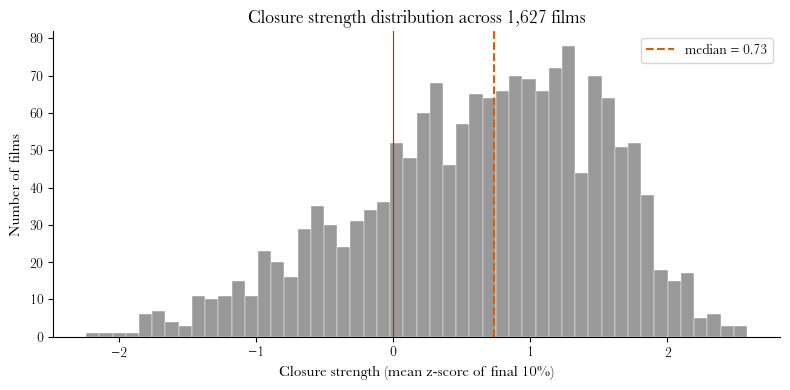

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(closure['closure_strength'].dropna(), bins=50, color='#999999', edgecolor='white', lw=0.3)
ax.axvline(0, color='red', lw=0.8)
ax.axvline(closure['closure_strength'].median(), color='#D95F02', lw=1.5, ls='--',
           label=f"median = {closure['closure_strength'].median():.2f}")
ax.set_xlabel('Closure strength (mean z-score of final 10%)')
ax.set_ylabel('Number of films')
ax.set_title('Closure strength distribution across 1,627 films')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/closure_level_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Interesting. I can see that most films end on a higher emotional note than their own average. The median sits at +0.73, which means the typical film in this corpus finishes noticeably above its own baseline mood. I wouldn't call this subtle. The bulk of the histogram clusters between +0.5 and +1.5, which tells me there's something like a default Hollywood instinct to resolve upward, and most films land in a pretty similar range when they do it. But there's a real tail on the left side. A few hundred films end below their own baseline, and they stretch further into negative territory than the positive side stretches into positive. So films that end high tend to end in a similar band, but films that end low vary a lot more in just how far down they're willing to go. The ceiling for euphoric endings is tighter than the floor for bleak ones.

## Section 5: Extremes

The films at the top and bottom of the closure strength ranking. This is the face-validity test. If I recognise the top as films that end on a genuine emotional high and the bottom as films that end cold or unresolved, the metric is working.

In [5]:
print('Highest closure strength')
print(closure.nlargest(15, 'closure_strength')[['title', 'year', 'closure_strength']].to_string(index=False))
print()
print('Lowest closure strength')
print(closure.nsmallest(15, 'closure_strength')[['title', 'year', 'closure_strength']].to_string(index=False))

Highest closure strength
                               title  year  closure_strength
                No One Will Save You  2023          2.581790
                         Chasing Amy  1997          2.577878
                  The Breakfast Club  1985          2.516631
                              Fences  2016          2.451048
                    Any Given Sunday  1999          2.433667
                           Nine Days  2020          2.430665
                                  It  2017          2.341758
National Lampoons Christmas Vacation  1989          2.336172
                            Sleepers  1996          2.330870
Harry Potter And The Sorcerers Stone  2001          2.309395
                          Paranorman  2012          2.302556
                 Lucky Number Slevin  2006          2.296693
                           Emergency  2022          2.272157
                      My Demon Lover  1987          2.242514
                          Four Rooms  1995          2.210235

## Section 6: Closure strength by decade

Has the way films end changed over the decades? I'll bucket the corpus into five decade bins and look at how the median closure strength shifts. If Hollywood endings have gotten bleaker (or more triumphant) over time, this should show it.

In [6]:
def year_to_decade(year):
    if   1980 <= year <= 1989: return "1980s"
    elif 1990 <= year <= 1999: return "1990s"
    elif 2000 <= year <= 2009: return "2000s"
    elif 2010 <= year <= 2019: return "2010s"
    elif 2020 <= year <= 2025: return "2020s"
    else: return "Other"

closure['decade'] = closure['year'].apply(year_to_decade)
decade_order = ["1980s", "1990s", "2000s", "2010s", "2020s"]

decade_stats = (
    closure[closure['decade'].isin(decade_order)]
    .groupby('decade')['closure_strength']
    .agg(['median', 'mean', 'std', 'count'])
    .reindex(decade_order)
)
print(decade_stats.round(3))

        median   mean    std  count
decade                             
1980s    0.678  0.608  0.901    214
1990s    0.788  0.640  0.909    287
2000s    0.691  0.607  0.909    310
2010s    0.753  0.649  0.862    569
2020s    0.748  0.634  0.898    247


/var/folders/b2/nk4ybyms6kg2d8lmwyqh28kh0000gn/T/ipykernel_825/1317703462.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(decade_data, labels=decade_order, patch_artist=True,


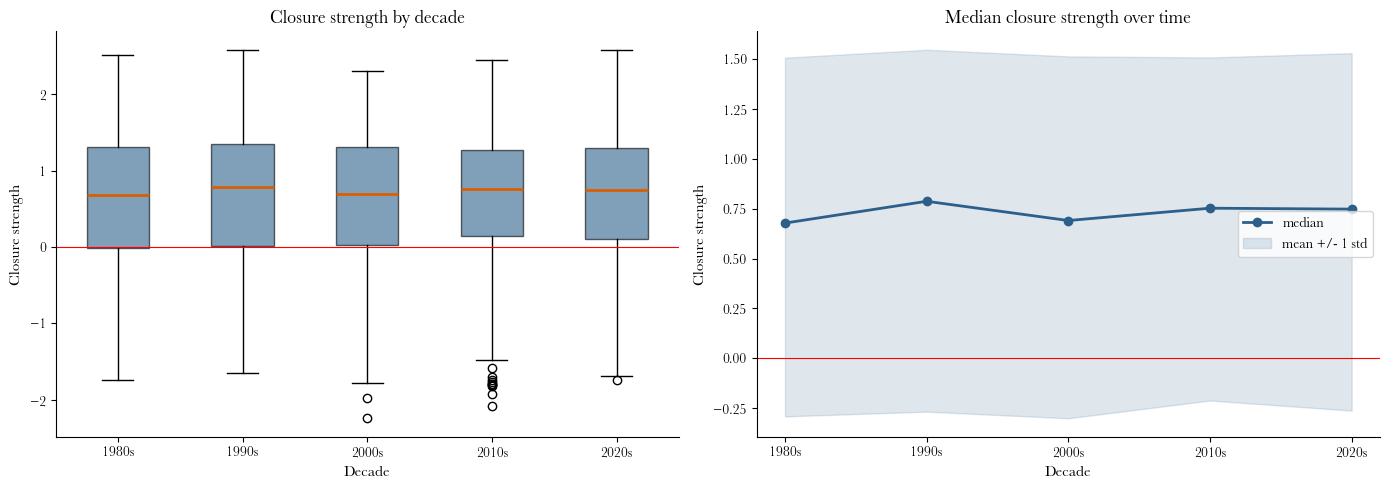

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
decade_data = [closure[closure['decade'] == d]['closure_strength'].dropna().values
               for d in decade_order]
bp = axes[0].boxplot(decade_data, labels=decade_order, patch_artist=True,
                     medianprops=dict(color='#D95F02', lw=2))
for patch in bp['boxes']:
    patch.set_facecolor('#2C5F8A')
    patch.set_alpha(0.6)
axes[0].axhline(0, color='red', lw=0.8)
axes[0].set_xlabel('Decade')
axes[0].set_ylabel('Closure strength')
axes[0].set_title('Closure strength by decade')
axes[0].spines[['top', 'right']].set_visible(False)

# Median trend line
axes[1].plot(decade_order, decade_stats['median'], marker='o', color='#2C5F8A', lw=2,
             label='median')
axes[1].fill_between(decade_order,
                     decade_stats['mean'] - decade_stats['std'],
                     decade_stats['mean'] + decade_stats['std'],
                     alpha=0.15, color='#2C5F8A', label='mean +/- 1 std')
axes[1].axhline(0, color='red', lw=0.8)
axes[1].set_xlabel('Decade')
axes[1].set_ylabel('Closure strength')
axes[1].set_title('Median closure strength over time')
axes[1].legend(fontsize=10)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/closure_strength_decades.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 7: Export

Writing out to CSV so I can join this with the rest of the per-film features later.

In [8]:
out_path = OUTPUT_DIR / 'closure_strength.csv'
closure.to_csv(out_path, index=False)
print(f'Wrote {out_path}  ({len(closure)} rows)')

Wrote ../docs/thesis-outputs/closure_strength.csv  (1627 rows)
